# Miami Plot

In this notebook we intend to show how can be used the library `IDEAL-GENOM` to generate a Miami Plot. 

In [1]:
import sys
import os

import pandas as pd

In [2]:
# add parent directory to path
library_path = os.path.abspath('..')
if library_path not in sys.path:
    sys.path.append(library_path)

In [3]:
from ideal_genom.visualizations.manhattan_type import miami_draw
from ideal_genom.core.get_examples import get_bmi_japanese_gwas, get_bmi_japanese_gwas_sex_dependent

The data is taken from the article

Akiyama, M., Okada, Y., Kanai, M. et al. Genome-wide association study identifies 112 new loci for body mass index in the Japanese population. *Nat Genet* **49**, 1458–1467 (2017). https://doi.org/10.1038/ng.3951

To draw this plot, we use summary statistics generated for males and females. 

In [4]:
gwas_f, gwas_m = get_bmi_japanese_gwas()

2026-01-26 12:54:03,666 - INFO - Downloading file: https://humandbs.dbcls.jp/files/hum0014/hum0014.v6.158k.v1.zip to /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/hum0014.v6.158k.v1.zip
2026-01-26 12:56:25,604 - INFO - Extracting file: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/hum0014.v6.158k.v1.zip
2026-01-26 12:56:26,557 - INFO - Extracting file: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/hum0014.v6.158k.v1.zip


Extracted: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/Female_2017_BMI_BBJ_autosome.txt.gz


2026-01-26 12:56:27,592 - INFO - Decompressing file: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/Female_2017_BMI_BBJ_autosome.txt.gz


Extracted: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/Male_2017_BMI_BBJ_autosome.txt.gz
Deleted ZIP file: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/hum0014.v6.158k.v1.zip


2026-01-26 12:56:31,666 - INFO - Decompressing file: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/Male_2017_BMI_BBJ_autosome.txt.gz


Decompressed: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/Female_2017_BMI_BBJ_autosome.txt
Removed original .gz file: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/Female_2017_BMI_BBJ_autosome.txt.gz
Decompressed: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/Male_2017_BMI_BBJ_autosome.txt
Removed original .gz file: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/Male_2017_BMI_BBJ_autosome.txt.gz


In [5]:
df_F = pd.read_csv(gwas_f, sep='\t')
df_M = pd.read_csv(gwas_m, sep='\t')

Please, provide the columns to load from the **GWAS** summary statistics. The essential columns are those that contains chromosome, base-pair position, rsID and p-value. It is important to remark that columns names most coincide in both files, at least for the four columns that will be used to generate the Miami plot.

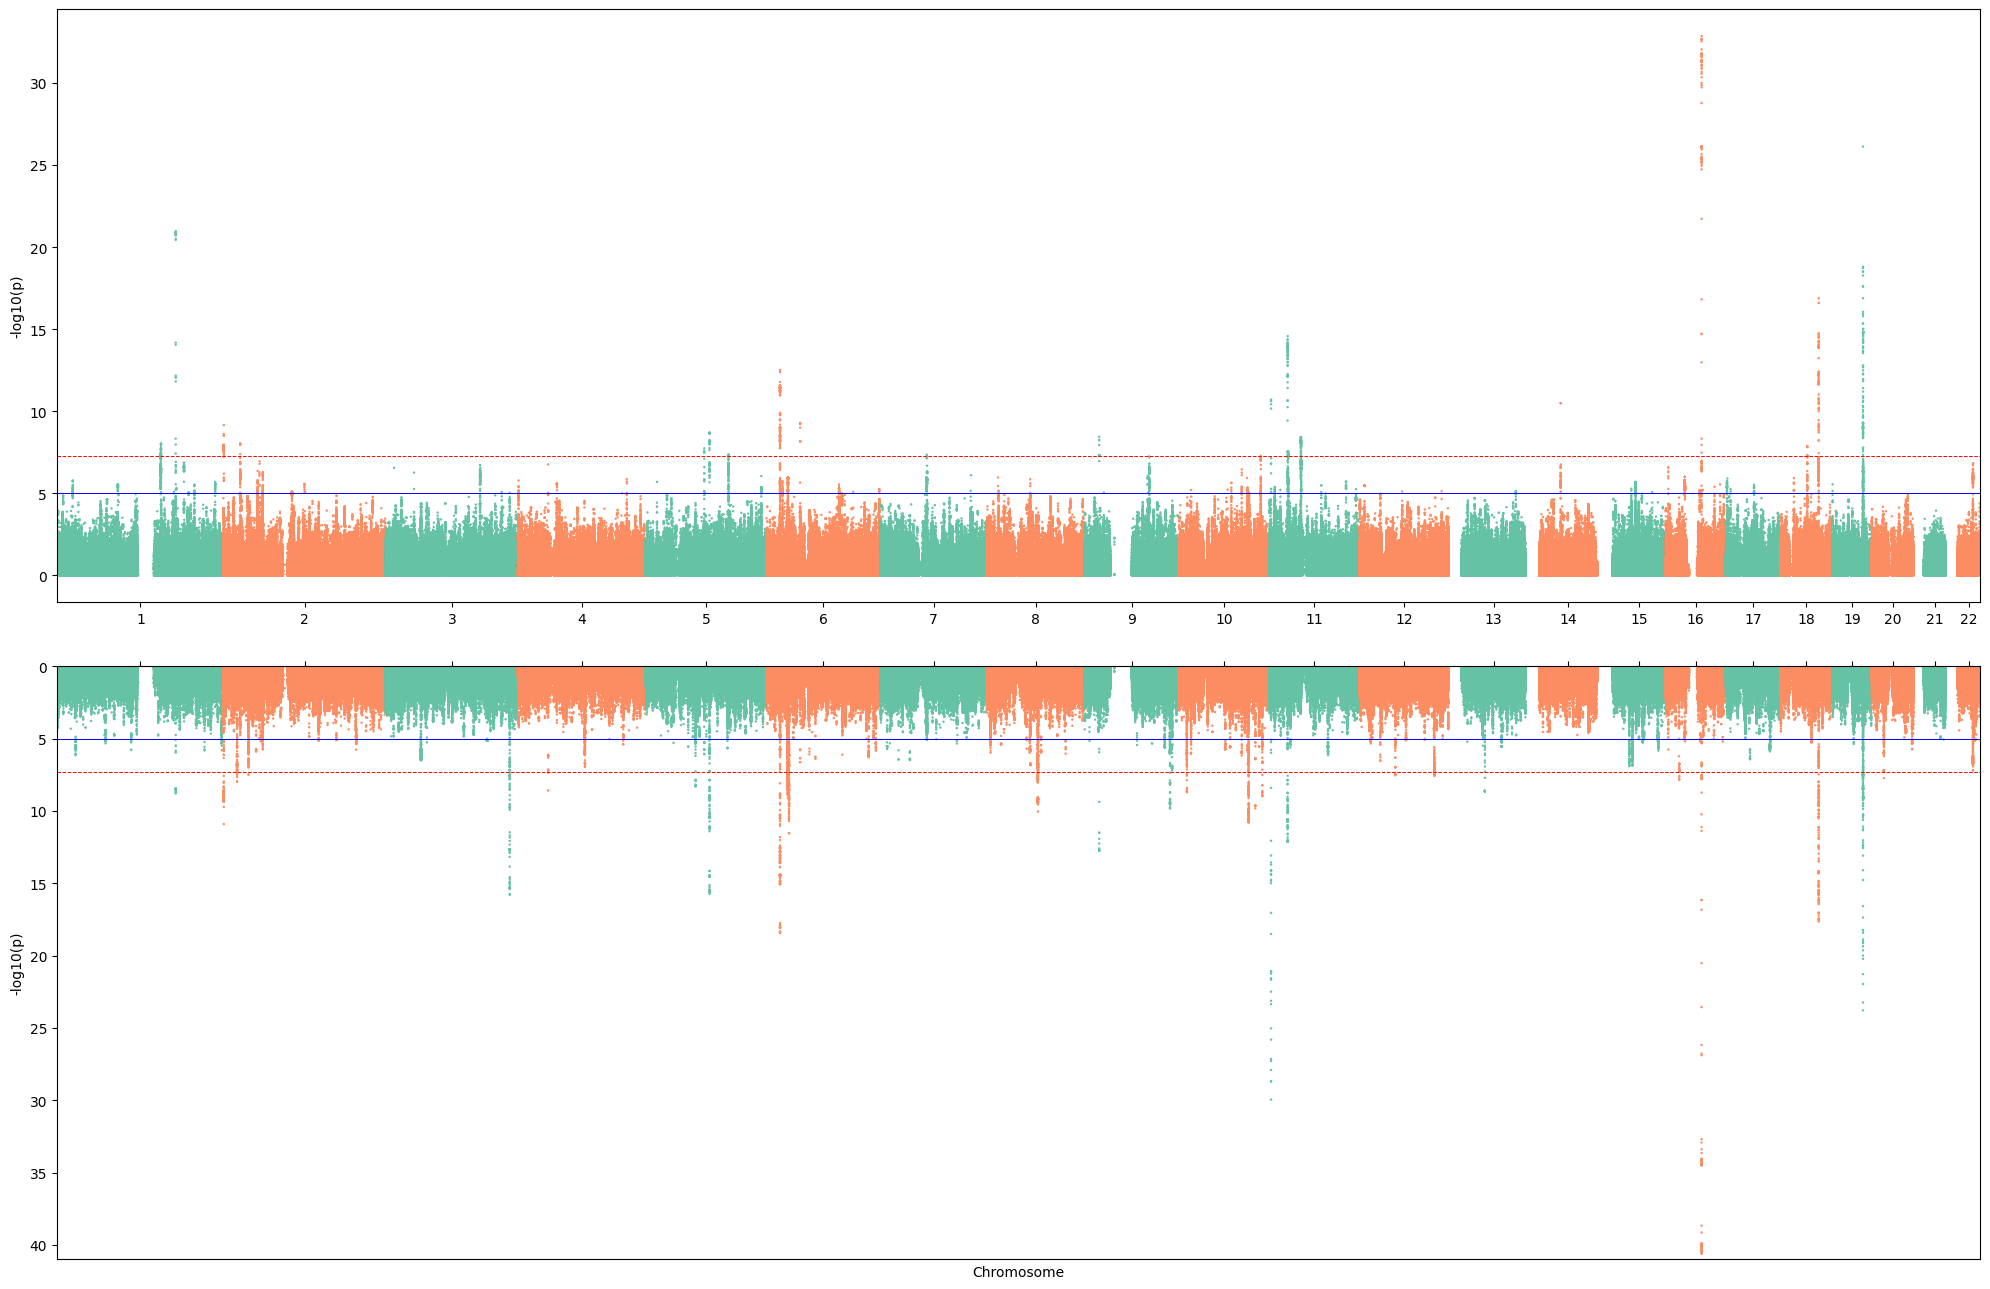

True

In [6]:
miami_draw(
    df_top            =df_F,
    df_bottom         =df_M,
    snp_col           ='SNP',
    chr_col           ='CHR',
    pos_col           ='POS',
    p_col             ='P',
    plots_dir         =gwas_f.parent.as_posix(), 
    save_name         ='miami_plot_female_vs_male.png',
)

In the reference study there is no a separated list of top hits for males and females, so let us make a fake list of the SNPs with lowest $p$-values.

In [7]:
df_top_hlite = df_F[df_F['P'] < 5e-16]['SNP'].to_list()
df_bottom_hlite = df_M[df_M['P'] < 5e-16]['SNP'].to_list()

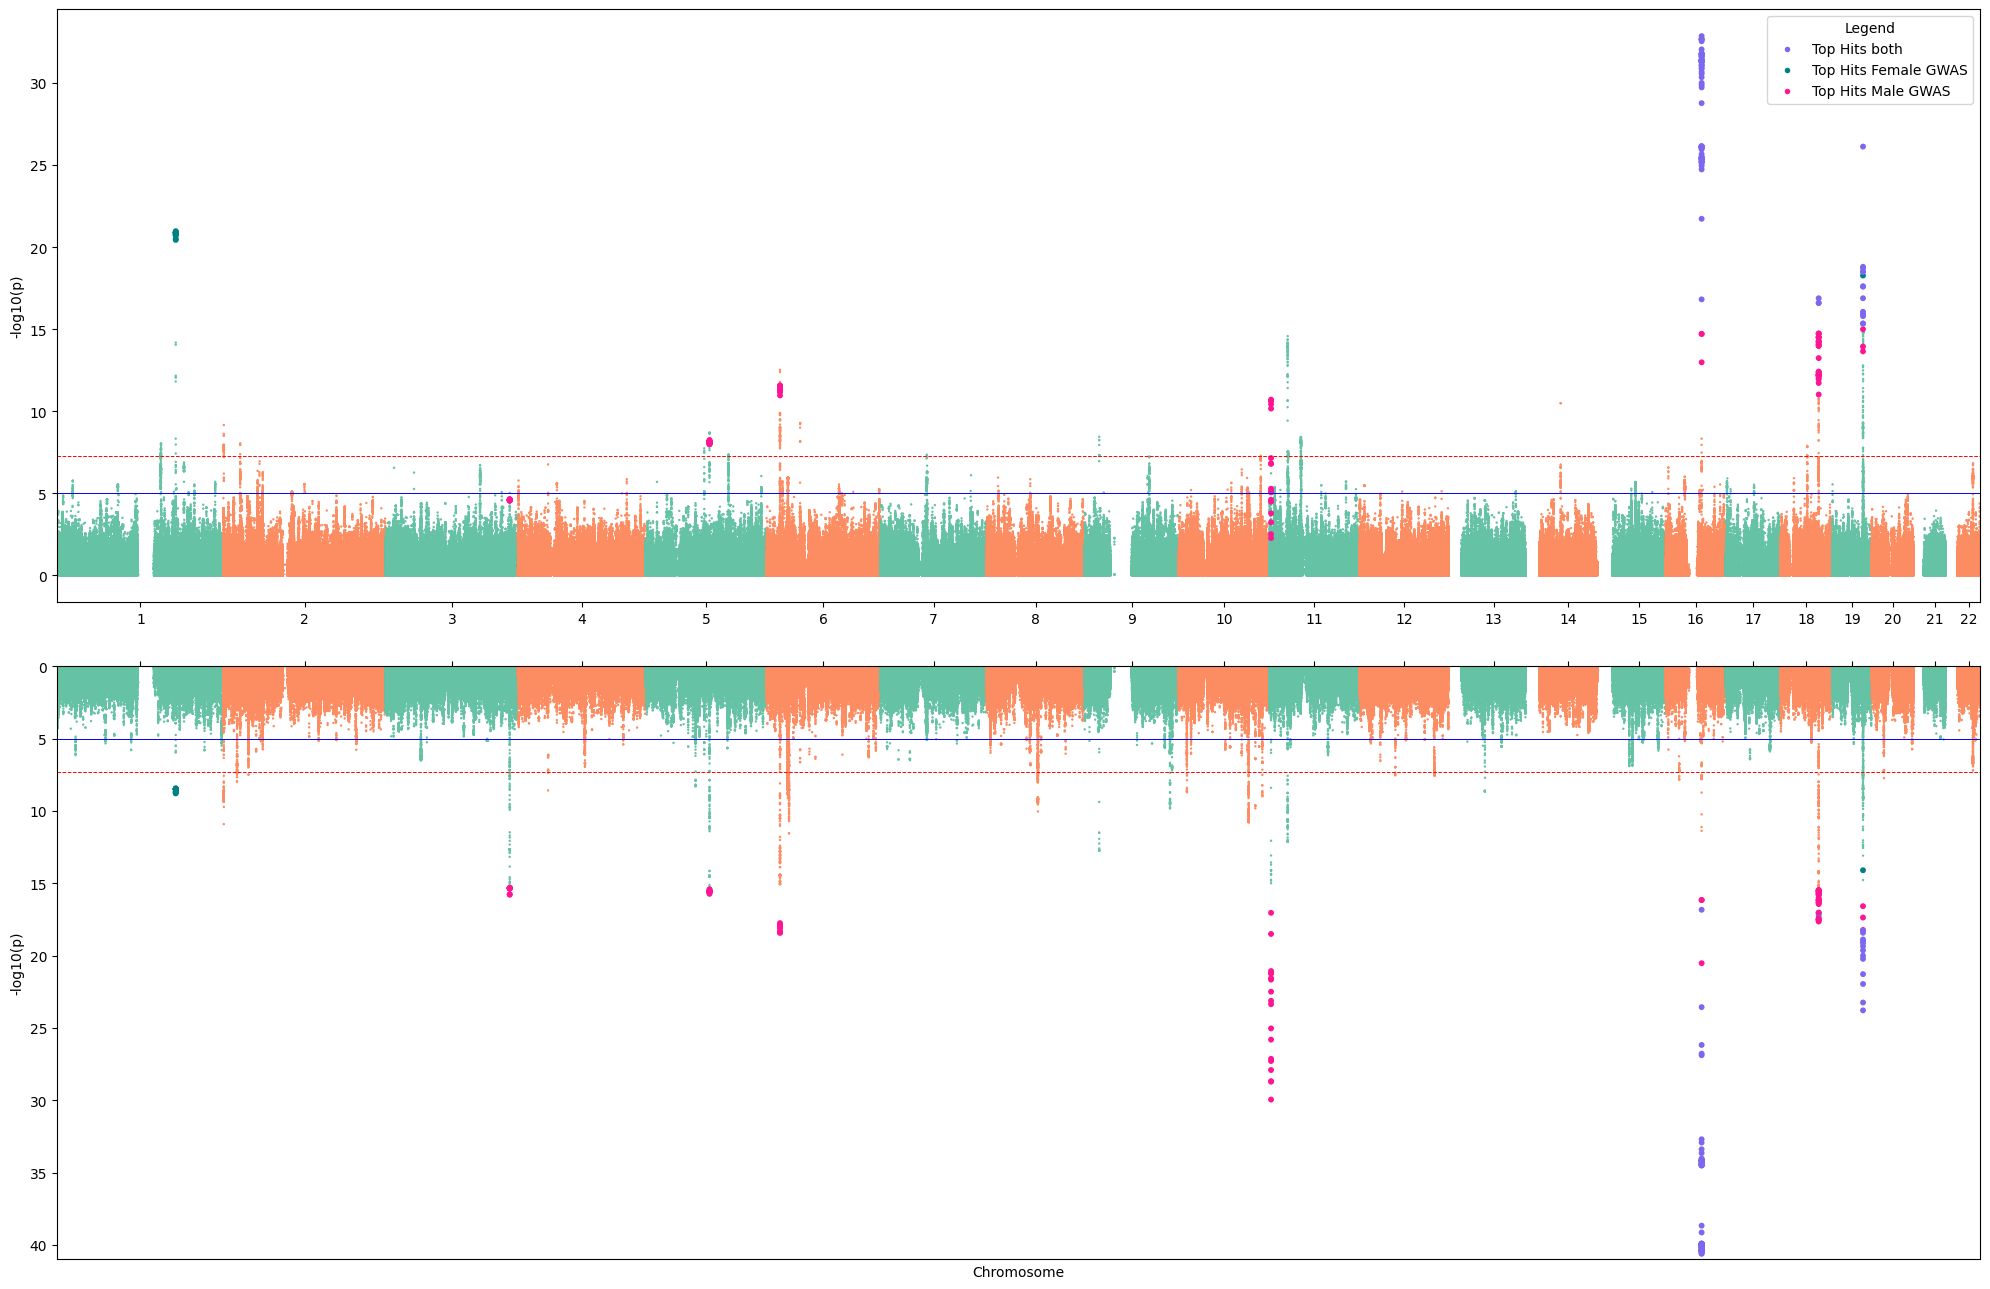

True

In [8]:
miami_draw(
    df_top            =df_F,
    df_bottom         =df_M,
    snp_col           ='SNP',
    chr_col           ='CHR',
    pos_col           ='POS',
    p_col             ='P',
    plots_dir         =gwas_f.parent.as_posix(),
    top_highlights    =df_top_hlite,
    bottom_highlights=df_bottom_hlite,
    legend_top        ='Female GWAS',
    legend_bottom     ='Male GWAS',
    save_name         ='miami_plot_female_vs_male_hlite.png',
)

In [9]:
anno_path = get_bmi_japanese_gwas_sex_dependent()

df_anno = pd.read_csv(anno_path, sep='\t')

2026-01-26 13:25:19,868 - INFO - File already exists: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/2017_BBJ_bmi_supplementary.csv


In [ ]:
miami_draw(
    df_top            =df_F,
    df_bottom         =df_M,
    snp_col           ='SNP',
    chr_col           ='CHR',
    pos_col           ='POS',
    p_col             ='P',
    plots_dir         =gwas_f.parent.as_posix(),
    top_highlights    =df_top_hlite,
    top_annotations   = df_anno[df_anno['Sex']=='Female'][['SNP']].reset_index(drop=True),
    bottom_highlights =df_bottom_hlite,
    bottom_annotations= df_anno[df_anno['Sex']=='Male'][['SNP']].reset_index(drop=True),
    legend_top        ='Female GWAS',
    legend_bottom     ='Male GWAS',
    save_name         ='miami_plot_female_vs_male_anno.png',
    source='ensembl',
    build='37'
)

2026-01-26 13:27:17,173 - INFO - Starting to annotate variants with nearest gene name(s)...
2026-01-26 13:27:17,174 - INFO -  -Using 37 as genome build
2026-01-26 13:27:17,175 - INFO - is_gtf_path set to False
2026-01-26 13:27:17,175 - INFO -  -Using ensembl as source for gene annotation
2026-01-26 13:27:17,176 - INFO -  -Assigning Gene name using Ensembl GRCh37 for protein coding genes
2026-01-26 13:27:17,177 - INFO -  -Downloading Ensembl GRCh37 GTF file
2026-01-26 13:27:17,497 - INFO - Latest GTF file: Homo_sapiens.GRCh37.87.chr.gtf.gz
2026-01-26 13:27:17,498 - INFO - Download URL: https://ftp.ensembl.org/pub/grch37/release-115/gtf/homo_sapiens/Homo_sapiens.GRCh37.87.chr.gtf.gz
2026-01-26 13:27:17,501 - INFO - File already exists: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/ensembl_latest/Homo_sapiens.GRCh37.87.chr.gtf.gz
2026-01-26 13:27:17,503 - INFO - File already exists: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/ensembl_latest/Homo_sapiens.GRCh37.87.chr.gtf
2026-01-26 13:2